In [7]:
import os
import re
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap


from patsy import dmatrices
import bambi as bmb
import arviz as az
from scipy.stats import chi2
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import display
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from util import *

sns.set_palette('colorblind')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [8]:
file_path = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/new/control/ny_1'

In [9]:
msnbc_urls = [
    "https://www.instagram.com/msnbc/reel/DQz6GiKkqD-/",
    "https://www.instagram.com/msnbc/reel/DQzvigyiu3R/",
    "https://www.instagram.com/msnbc/reel/DQzaxBeisq2/",
    "https://www.instagram.com/msnbc/reel/DQzOhJyil7B/",
    "https://www.instagram.com/msnbc/reel/DQx_MsXDdqz/",
    "https://www.instagram.com/reel/DQx6d6TDFvD/",
    "https://www.instagram.com/reel/DQxz17nkXAu/",
    "https://www.instagram.com/reel/DQxxwsjEQxy/",
    "https://www.instagram.com/reel/DQxf5uvERD0/",
    "https://www.instagram.com/reel/DQxc21kkqwR/",
]

huffpost_urls = [
    "https://www.instagram.com/huffpost/reel/DQzSuMQARR0/",
    "https://www.instagram.com/huffpost/p/DQxLW-PEns-/",
    "https://www.instagram.com/huffpost/reel/DQxARFuAbt-/",
    "https://www.instagram.com/huffpost/reel/DQw6Qa_kWgY/",
    "https://www.instagram.com/huffpost/reel/DQw5_xHkWod/",
    "https://www.instagram.com/huffpost/reel/DQwbCxQjQNQ/",
    "https://www.instagram.com/huffpost/p/DQu2w59E9t-/",
    "https://www.instagram.com/huffpost/reel/DQvEm2FDCmz/",
    "https://www.instagram.com/huffpost/p/DQuw7U7D322/",
    "https://www.instagram.com/p/DQujjUrk61E/"
]

cnn_urls = [
    "https://www.instagram.com/reel/DQ0VgDjjx7K/",
    "https://www.instagram.com/p/DQ0LWj6jue3/",
    "https://www.instagram.com/reel/DQz7vqJiEUj/",
    "https://www.instagram.com/reel/DQznNr7gp1F/",
    "https://www.instagram.com/reel/DQzgXgPgPmN/",
    "https://www.instagram.com/reel/DQzNYM8ARN3/",
    "https://www.instagram.com/reel/DQzEp0pChCY/",
    "https://www.instagram.com/reel/DQy-AdiCcH_/",
    "https://www.instagram.com/reel/DQyzpQVjga4/",
    "https://www.instagram.com/reel/DQypWvmDoge/"
]

washingtonpost_urls = [
    "https://www.instagram.com/washingtonpost/p/DQ0JgL9DqcC/",
    "https://www.instagram.com/washingtonpost/p/DQz7wRODMr8/",
    "https://www.instagram.com/washingtonpost/p/DQzuD3fFJcu/",
    "https://www.instagram.com/washingtonpost/reel/DQzh-t0DSAJ/",
    "https://www.instagram.com/washingtonpost/reel/DQzgTDHAcKl/",
    "https://www.instagram.com/p/DQzZihPDiQv/",
    "https://www.instagram.com/reel/DQzSo12D1fJ/",
    "https://www.instagram.com/reel/DQzLtq3ARq3/",
    "https://www.instagram.com/p/DQxxk6BDvZh/",
    "https://www.instagram.com/p/DQxqaCpDcHC/"
]

forbes_urls = [
    "https://www.instagram.com/forbes/p/DQ0Ck-lgUxt/",
    "https://www.instagram.com/forbes/p/DQz0444AWAd/",
    "https://www.instagram.com/forbes/p/DQzgP9_gcjC/",
    "https://www.instagram.com/p/DQzUOiGAblX/",
    "https://www.instagram.com/p/DQzLpqJDxMD/",
    "https://www.instagram.com/p/DQzFWzxkT-c/",
    "https://www.instagram.com/p/DQxdypCDPF2/",
    "https://www.instagram.com/p/DQxOpmbkn_b/",
    "https://www.instagram.com/p/DQxFjBJj4gS/",
    "https://www.instagram.com/p/DQxElAzD6aK/"
]

thehill_urls = [
    "https://www.instagram.com/thehill/p/DQzfVDcE3YB/",
    "https://www.instagram.com/thehill/p/DQxg1ufkeqR/",
    "https://www.instagram.com/thehill/reel/DQxViLFEdQ5/",
    "https://www.instagram.com/thehill/p/DQw1LZxEwrn/",
    "https://www.instagram.com/thehill/p/DQwgkZxD2Ug/",
    "https://www.instagram.com/thehill/reel/DQvAK9hEeWU/",
    "https://www.instagram.com/thehill/p/DQunQLokn-7/",
    "https://www.instagram.com/thehill/reel/DQuNa5zEeiR/",
    "https://www.instagram.com/thehill/p/DQt9lxsjumG/",
    "https://www.instagram.com/reel/DQrpC35EXqn/"
]

washingtontimes_urls = [
    "https://www.instagram.com/washtimes/p/DQz0CxJExjr/",
    "https://www.instagram.com/washtimes/p/DQzcWsGkg8C/",
    "https://www.instagram.com/washtimes/p/DQxHICQE_29/",
    "https://www.instagram.com/washtimes/p/DQw_V8sE6ZH/",
    "https://www.instagram.com/washtimes/p/DQw3jz6k0L6/",
    "https://www.instagram.com/washtimes/p/DQwvq-dktiv/",
    "https://www.instagram.com/washtimes/p/DQwn4b2EzCR/",
    "https://www.instagram.com/washtimes/p/DQwgGZ2jQck/",
    "https://www.instagram.com/washtimes/p/DQvCB1iEwBa/",
    "https://www.instagram.com/washtimes/reel/DQu5zA1CL3U/"
]

nypost_urls = [
    "https://www.instagram.com/p/DQ0Jd_SAc4Z/",
    "https://www.instagram.com/p/DQ0GBAngWyx/",
    "https://www.instagram.com/reel/DQ0ETkoDtLN/",
    "https://www.instagram.com/p/DQ0ClEugU1r/",
    "https://www.instagram.com/p/DQz_JRkAWr9/",
    "https://www.instagram.com/reel/DQz9kQIDZOc/",
    "https://www.instagram.com/p/DQz70tPAQTn/",
    "https://www.instagram.com/p/DQz4Y1Xgadc/",
    "https://www.instagram.com/reel/DQz2rWGEkpe/",
    "https://www.instagram.com/p/DQz09vagSe1/"
]

foxnews_urls = [
    "https://www.instagram.com/reel/DQ0V_qAEfwE/",
    "https://www.instagram.com/reel/DQ0UdiODE-2/",
    "https://www.instagram.com/reel/DQ0UNIZD3rv/",
    "https://www.instagram.com/reel/DQ0OfgWAswZ/",
    "https://www.instagram.com/reel/DQ0OAwCk91U/",
    "https://www.instagram.com/reel/DQ0GaXEjofE/",
    "https://www.instagram.com/reel/DQ0ClztkmYz/",
    "https://www.instagram.com/p/DQ0AYUTkvh4/",
    "https://www.instagram.com/p/DQz8ZTUjJ4s/",
    "https://www.instagram.com/reel/DQz8UW2j4TQ/"
]

breitbart_urls = [
    "https://www.instagram.com/p/DQ0P_UtDFLj/",
    "https://www.instagram.com/p/DQ0ImR1DaM0/",
    "https://www.instagram.com/p/DQz28XJkuQV/",
    "https://www.instagram.com/p/DQzkN12CUZQ/",
    "https://www.instagram.com/reel/DQzXuPOkgOo/",
    "https://www.instagram.com/p/DQzR5CjkQxS/",
    "https://www.instagram.com/p/DQzJCenDSPC/",
    "https://www.instagram.com/p/DQy1VfcETEi/",
    "https://www.instagram.com/reel/DQxZ3LCkvgh/",
    "https://www.instagram.com/p/DQxfi8JjVGb/"
]

all_urls = {
    'msnbc': msnbc_urls,
    'huffpost': huffpost_urls,
    'cnn': cnn_urls,
    'washingtonpost': washingtonpost_urls,
    'forbes': forbes_urls,
    'thehill': thehill_urls,
    'washingtontimes': washingtontimes_urls,
    'nypost': nypost_urls,
    'foxnews': foxnews_urls,
    'breitbart': breitbart_urls
}

In [10]:
all_crawls = os.listdir(file_path)
all_crawls

['2025-12-07 15:37:20',
 '2025-12-08 06:32:00',
 '2025-12-08 01:32:00',
 '2025-12-07 20:32:04']

### Merging and preprocessing

In [5]:
dfs = {}
for crawl in all_crawls:
    temp_list = []
    for account in all_urls.keys():
        # this file is missing in the data crawl. 
        if account == 'breitbart' and crawl == '2025-12-08 06:32:00':
            continue


        accountfiles = os.listdir(f'{file_path}/{crawl}/{account}')
        file_ids = list({re.split(r'_(comments|timestamps)', fp)[0] for fp in accountfiles})

        for id_ in file_ids:

            # if both comments and timestamps files are present
            if f'{id_}_comments.json' in accountfiles and f'{id_}_timestamps.json' in accountfiles:

                with open(f'{file_path}/{crawl}/{account}/{id_}_comments.json', 'r') as f:
                    comments = json.load(f)
                with open(f'{file_path}/{crawl}/{account}/{id_}_timestamps.json', 'r') as f:
                    timestamps = json.load(f)
                
                caption, comments, likes = clean_comments(comments)

                # this particular comment is just ' '. so adding it manually.
                id_user_mapping = {
                    'DRVQXcWAaaw': 'authoryuccaharris',
                    'DSBZZEcgL4D': 'mafia__460mafia_', 
                    'DSBm_S8gC1p': 'grimreaper3716',
                    'DRYdTZHjT-E': 'danieleichenlaub',
                    'DSARqDnEhPJ': 'amadeoedgardof',
                    'DR_mqpKEr01': 'amadeoedgardof',
                    'DSC60BKkrYV': 'amadeoedgardof',
                    'DR5O3P_jycm': 'dottyeroth',
                    'DSCrwGuDxUR': 'treqpimento_',
                    'DSEn813Eo5Q': 'amadeoedgardof'

                }

                if id_ in id_user_mapping:
                    if id_user_mapping[id_] in comments:
                        idx = comments.index(id_user_mapping[id_])
                        comments = comments[:idx+1] + [' '] + comments[idx+1:]

                # mapping usernames and comments to timestamps
                comments_map = {}

                # checking if comments (username + comment) and timestamps are of same length 
                if len(comments) == 2*len(timestamps):

                    if len(comments) % 2 == 0:

                        usernames = comments[::2]
                        comments_text = comments[1::2]

                        
                        for u, c, t in zip(usernames, comments_text, timestamps):
                            comments_map[(u, c)] = t

                        idx = 0
                        for c, v in comments_map.items():
                            temp_dict = {'account': account,
                                         'urlid': id_,
                                         'caption': caption,
                                         'comment_num': idx,
                                         f'{crawl}_comment': c,
                                         f'{crawl}_timestamp': v,
                                         'likes': likes} # TODO: check if likes here is correct
                            idx += 1
                            temp_list.append(temp_dict)

                else:
                    # if this happens, its mostly happening since a comment is empty string ''
                    print(f'comemnts-timestamps length mismatch', account, id_, crawl)
            else:
                # only comments file is present
                with open(f'{file_path}/{crawl}/{account}/{id_}_comments.json', 'r') as f:
                    comments = json.load(f)

                caption, comments, likes = clean_comments(comments)
                if len(comments) != 0:
                    if id_ == 'DSC60BKkrYV':
                        caption, comments, likes = None, [], None
                    else:
                        print('no timestamp file and len(comments) != 0', id_, account, crawl, len(comments))
                    
                    # if this happens its usually to do more cleaning of comements

    df = pd.DataFrame(temp_list)
    dfs[crawl] = df

no timestamp file and len(comments) != 0 DRXw_eDjr9l washingtonpost 2025-12-07 20:32:04 2


In [6]:
for crawl, df in dfs.items():
    print(f'{crawl}: {df.shape}')

2025-12-07 15:37:20: (1175, 7)
2025-12-08 06:32:00: (1019, 7)
2025-12-08 01:32:00: (1176, 7)
2025-12-07 20:32:04: (1158, 7)


In [7]:
for crawl, df in dfs.items():
    df.drop(columns=['caption', 'likes'], inplace=True, axis=1)

In [8]:
# merging all dfs

merged_df = dfs['2025-12-07 15:37:20'].copy()

for crawl, df in dfs.items():
    if crawl == '2025-12-07 15:37:20':
        continue
    print(crawl)
    merged_df = pd.merge(merged_df, df, how='outer', on=['account', 'urlid', 'comment_num'])

2025-12-08 06:32:00
2025-12-08 01:32:00
2025-12-07 20:32:04


In [9]:
# remove urls that have less than 10 comments

urlids = merged_df['urlid'].unique().tolist()
donotremove_urls = set()
for urlid in urlids:
    temp = merged_df[merged_df['urlid'] == urlid]
    num_rows = temp['comment_num'].max()
    if num_rows <= 8:
        continue
    else:
        donotremove_urls.add(urlid)

merged_df = merged_df[merged_df['urlid'].isin(donotremove_urls)]

In [10]:
# limiting to top 10 comments
merged_df = merged_df[merged_df['comment_num'] <= 9]
merged_df.shape

(860, 11)

In [11]:
temp_df = get_chronological_order_comments(merged_df, all_urls, all_crawls)
merged_df = pd.merge(merged_df, temp_df, how='outer', on=['account', 'urlid', 'comment_num'])

In [12]:
merged_df.drop(columns=[x for x in merged_df.columns if 'timestamp' in x], inplace=True)
merged_df.head()

,account,urlid,comment_num,2025-12-07 15:37:20_comment,2025-12-08 06:32:00_comment,2025-12-08 01:32:00_comment,2025-12-07 20:32:04_comment,chronological_comment
0,breitbart,DRWBiQXDG0H,0,"(torinejudith, ❤️)",NaN,"(torinejudith, ❤️)","(torinejudith, ❤️)","(happenings_25, This administration just cance..."
1,breitbart,DRWBiQXDG0H,1,"(terp00, Maga died when trump went Israel firs...",NaN,"(terp00, Maga died when trump went Israel firs...","(terp00, Maga died when trump went Israel firs...","(ryan.smith202, It’s not fissures in MAGA, it ..."
2,breitbart,DRWBiQXDG0H,2,"(scottishlyme, The actual LEFT should be calle...",NaN,"(scottishlyme, The actual LEFT should be calle...","(scottishlyme, The actual LEFT should be calle...","(terp00, Maga died when trump went Israel firs..."
3,breitbart,DRWBiQXDG0H,3,"(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...",NaN,"(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(_taco_______, 🤡🤡)"
4,breitbart,DRWBiQXDG0H,4,"(ryan.smith202, It’s not fissures in MAGA, it ...",NaN,"(i_tr00per, Bernie Moreno has the most remedia...","(ryan.smith202, It’s not fissures in MAGA, it ...","(loretta.bauer.35, I thought that was exactly ..."


In [13]:
merged_df.shape

(1035, 8)

In [14]:
# merged_df.to_excel('temp.xlsx')

### Plotting Differences

In [14]:
merged_df.head()

,account,urlid,comment_num,2025-12-07 15:37:20_comment,2025-12-08 06:32:00_comment,2025-12-08 01:32:00_comment,2025-12-07 20:32:04_comment,chronological_comment
0,breitbart,DRWBiQXDG0H,0,"(torinejudith, ❤️)",NaN,"(torinejudith, ❤️)","(torinejudith, ❤️)","(happenings_25, This administration just cance..."
1,breitbart,DRWBiQXDG0H,1,"(terp00, Maga died when trump went Israel firs...",NaN,"(terp00, Maga died when trump went Israel firs...","(terp00, Maga died when trump went Israel firs...","(ryan.smith202, It’s not fissures in MAGA, it ..."
2,breitbart,DRWBiQXDG0H,2,"(scottishlyme, The actual LEFT should be calle...",NaN,"(scottishlyme, The actual LEFT should be calle...","(scottishlyme, The actual LEFT should be calle...","(terp00, Maga died when trump went Israel firs..."
3,breitbart,DRWBiQXDG0H,3,"(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...",NaN,"(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(_taco_______, 🤡🤡)"
4,breitbart,DRWBiQXDG0H,4,"(ryan.smith202, It’s not fissures in MAGA, it ...",NaN,"(i_tr00per, Bernie Moreno has the most remedia...","(ryan.smith202, It’s not fissures in MAGA, it ...","(loretta.bauer.35, I thought that was exactly ..."


In [16]:
crawl1 = 'chronological'
crawl2 = '2025-12-07 15:37:20'

temp_df = merged_df.copy()
account_fprops_no_rank, account_fprops_rank, temp_df = compute_fprops(crawl1, crawl2, temp_df, all_urls)

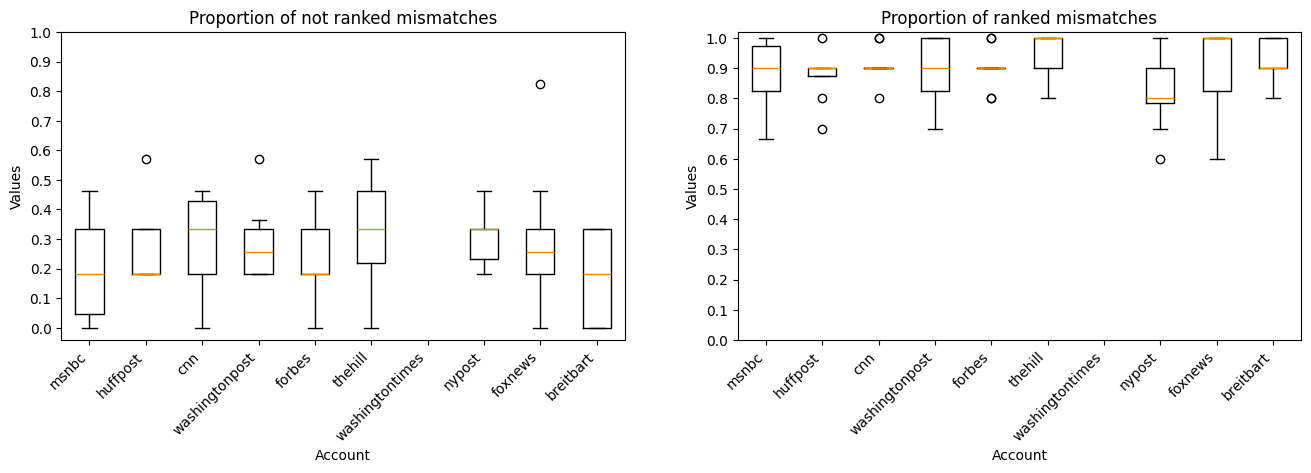

In [17]:
accounts = list(account_fprops_no_rank.keys())
values_no_rank = [account_fprops_no_rank[acc] for acc in accounts]
values_rank = [account_fprops_rank[acc] for acc in accounts]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

ax1.boxplot(values_no_rank, tick_labels=accounts)
ax1.set_title("Proportion of not ranked mismatches")
ax1.set_xlabel("Account")
ax1.set_ylabel("Values")
ax1.set_xticks(range(1, 11))
ax1.set_xticklabels(accounts, rotation=45, ha='right')
ax1.set_yticks(np.arange(0, 1.1, 0.1))

ax2.boxplot(values_rank, tick_labels=accounts)
ax2.set_title("Proportion of ranked mismatches")
ax2.set_xlabel("Account")
ax2.set_ylabel("Values")
ax2.set_xticks(range(1, 11))
ax2.set_xticklabels(accounts, rotation=45, ha='right')
ax2.set_yticks(np.arange(0, 1.1, 0.1))

plt.show()

In [ ]:
mismatch_no_rank, mismatch_rank = {}, {}

for crawl1 in ['chronological'] + all_crawls:
    mismatch_no_rank[crawl1] = {}
    mismatch_rank[crawl1] = {}
    for crawl2 in all_crawls:
        mod_df = merged_df.copy()
        _, _, mod_df = compute_fprops(crawl1, crawl2, mod_df, all_urls)

        temp_df = mod_df[mod_df['comment_num'] == 0]
        mismatch_no_rank[crawl1][crawl2] = temp_df['fcount_no_rank'].sum() / temp_df['ftrials_no_rank'].sum()
        mismatch_rank[crawl1][crawl2] = temp_df['fcount_rank'].sum() / temp_df['ftrials_rank'].sum()

mismatch_rank_df = pd.DataFrame.from_dict(mismatch_rank, orient="index")
mismatch_no_rank_df = pd.DataFrame.from_dict(mismatch_no_rank, orient="index")

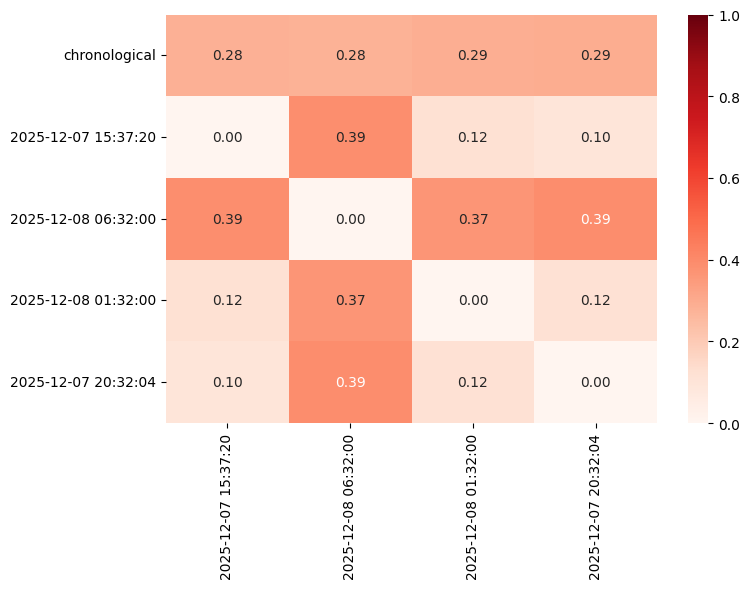

In [19]:
plt.figure(figsize=(8, 6)) 
sns.heatmap(mismatch_no_rank_df, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1)
plt.tight_layout()
plt.show()

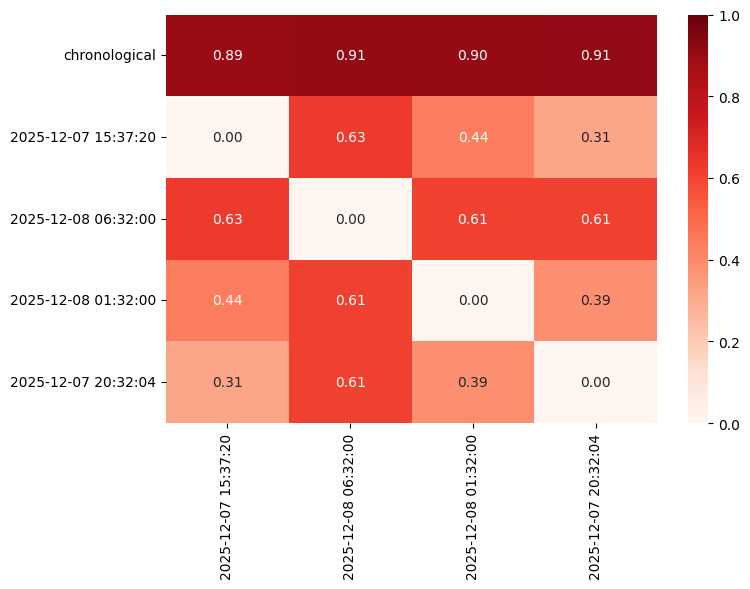

In [20]:
plt.figure(figsize=(8, 6)) 
sns.heatmap(mismatch_rank_df, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1)
plt.tight_layout()
plt.show()

#### Old graphs

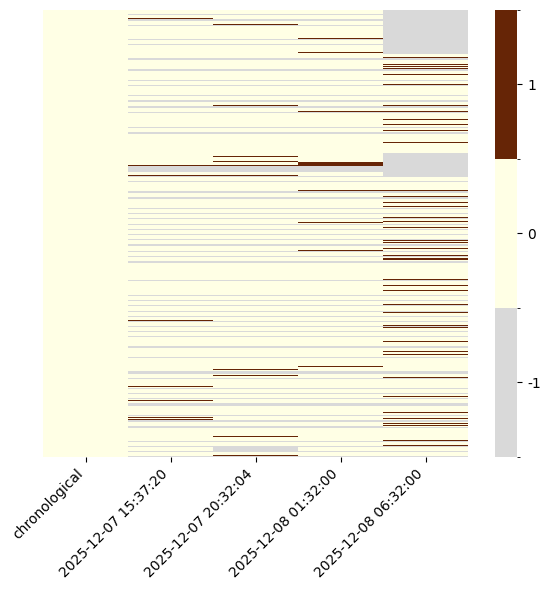

In [18]:
col1 = 'chronological_comment'
col2 = '2025-12-07 15:37:20_comment'
col3 = '2025-12-07 20:32:04_comment'
col4 = '2025-12-08 01:32:00_comment'
col5 = '2025-12-08 06:32:00_comment'

cols = [col1, col2, col3, col4, col5]

codes = []
for idx, x in zip(merged_df.index, zip(*(merged_df[c] for c in cols))):

    temp_code = []
    for i, a in enumerate(x):
        if pd.isna(a):
            code = -1
        else:
            acc_comments = []
            
            if i == 0:
                remove_col = col1
            elif i == 1:
                remove_col = col2
            elif i == 2:
                remove_col = col3
            elif i == 3:
                remove_col = col4
            elif i == 4:
                remove_col = col5

            for c in cols:
                if c == remove_col:
                    continue
                if c == col1:
                    continue
                acc = merged_df.loc[idx, 'account']
                url = merged_df.loc[idx, 'urlid']
                acc_comments += merged_df[(merged_df['account'] == acc) & (merged_df['urlid'] == url)][c].dropna().unique().tolist() 

            if a in set(acc_comments):
                code = 0
            else:
                code = 1

        temp_code.append(code)
    codes.append(temp_code)

codes = np.array(codes)

max_code = codes[codes >= 0].max() if np.any(codes >= 0) else -1
num_groups = max_code + 1

base_cmap = plt.cm.YlOrBr(np.linspace(0, 1, max(num_groups, 1)))
colors = np.vstack(([0.85, 0.85, 0.85, 1.0], base_cmap))
cmap = ListedColormap(colors)

bounds = np.arange(-1.5, num_groups + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(
    codes,
    annot=False,
    cmap=cmap,
    norm=norm,
    vmin=-1,
    vmax=max_code,
    cbar=True,                      
    linewidths=0,
    yticklabels=False,
    xticklabels=[c.replace('_comment', '') for c in cols],
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
cbar = ax.collections[0].colorbar
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels([
    "-1",
    "0",
    "1",
])

# optional: add dotted separators for groups (your urlid trick)
# indices = merged_df["urlid"].drop_duplicates().index
# for y in indices:
#     ax.hlines(y, *ax.get_xlim(), linestyles="dotted", linewidth=1, color="black")

plt.tight_layout()
plt.show()


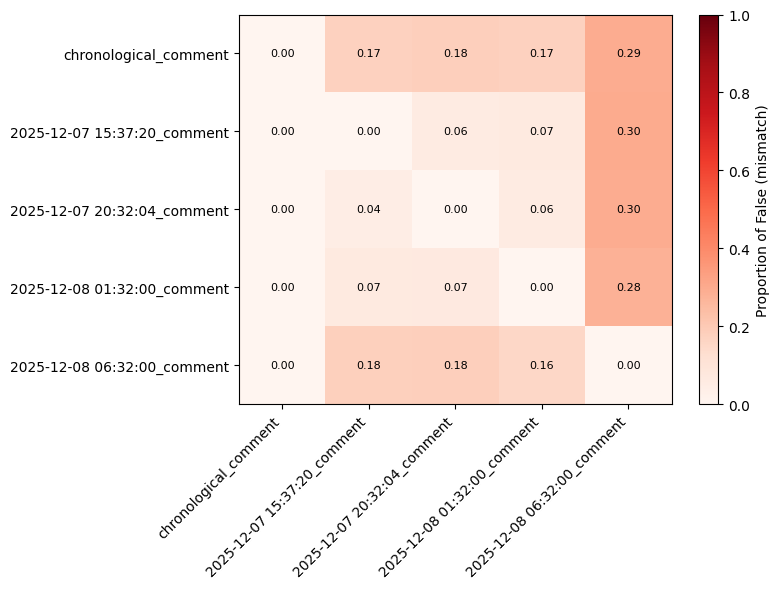

In [19]:
cols = [col1, col2, col3, col4, col5]
key_cols = ["account", "urlid"]

group_comments = {}
for key, g in merged_df.groupby(key_cols, sort=False):
    group_comments[key] = {
        col: set(g[col].dropna())
        for col in cols
    }

overall_not_covered = pd.DataFrame(index=cols, columns=cols, dtype=float)

for c1 in cols:
    for c2 in cols:
        if c1 == c2:
            overall_not_covered.loc[c1, c2] = 0.0
            continue

        total = 0
        not_covered = 0

        for key, d in group_comments.items():
            s1 = d[c1]
            s2 = d[c2]
            if not s1:
                continue

            total += len(s1)
            not_covered += len(s1 - s2)

        overall_not_covered.loc[c1, c2] = not_covered / total if total else 0.0



fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    overall_not_covered.values,
    aspect='auto',
    cmap='Reds',
    vmin=0, vmax=1
)

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticklabels(cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{overall_not_covered.iloc[i, j]:.2f}",
                ha='center', va='center', fontsize=8)

cbar = fig.colorbar(im, ax=ax, cmap='Blues')
cbar.set_label('Proportion of False (mismatch)')

plt.tight_layout()
plt.show()


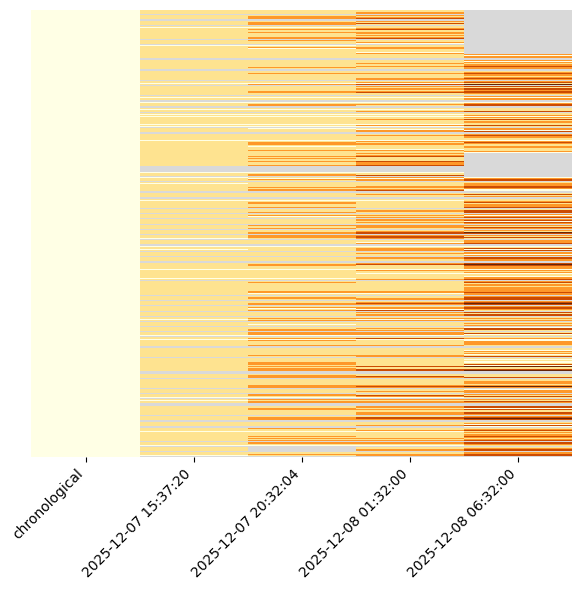

In [20]:
col1 = 'chronological_comment'
col2 = '2025-12-07 15:37:20_comment'
col3 = '2025-12-07 20:32:04_comment'
col4 = '2025-12-08 01:32:00_comment'
col5 = '2025-12-08 06:32:00_comment'

cols = [col1, col2, col3, col4, col5]

codes = []
for x in zip(*(merged_df[c] for c in cols)):
    present_already = []
    temp_code = []
    for a in x:
        if pd.isna(a):
            c = -1
        else:
            if a not in present_already:
                c = len(present_already)
                present_already.append(a)
            else:
                c = present_already.index(a)
        temp_code.append(c)
    codes.append(temp_code)

codes = np.array(codes)

max_code = codes[codes >= 0].max() if np.any(codes >= 0) else -1
num_groups = max_code + 1

base_cmap = plt.cm.YlOrBr(np.linspace(0, 1, max(num_groups, 1)))
colors = np.vstack(([0.85, 0.85, 0.85, 1.0], base_cmap))
cmap = ListedColormap(colors)

bounds = np.arange(-1.5, num_groups + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(
    codes,
    annot=False,
    cmap=cmap,
    norm=norm,
    vmin=-1,
    vmax=max_code,
    cbar=False,                      
    linewidths=0,
    yticklabels=False,
    xticklabels=[c.replace('_comment', '') for c in cols],
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# optional: add dotted separators for groups (your urlid trick)
# indices = merged_df["urlid"].drop_duplicates().index
# for y in indices:
#     ax.hlines(y, *ax.get_xlim(), linestyles="dotted", linewidth=1, color="black")

plt.tight_layout()
plt.show()


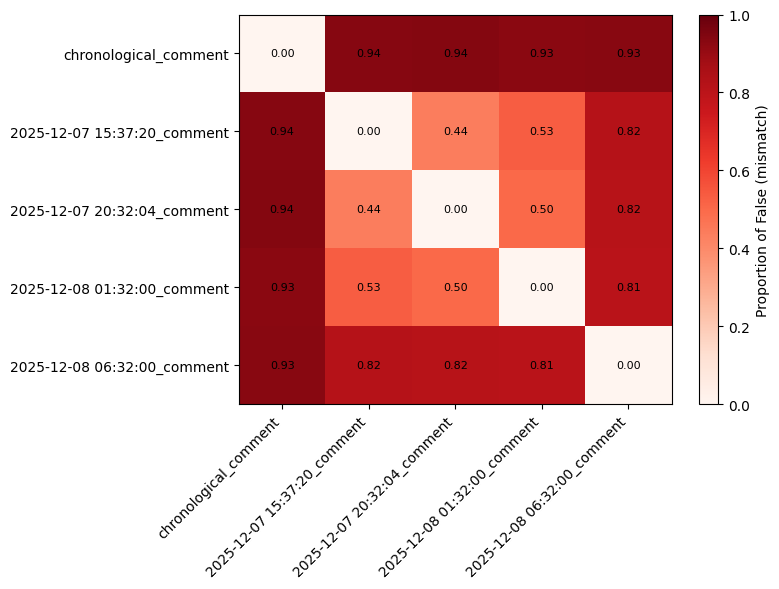

In [21]:
false_ratio = pd.DataFrame(index=cols, columns=cols, dtype=float)

for c1 in cols:
    for c2 in cols:
        if c1 == c2:
            false_ratio.loc[c1, c2] = 0.0
        else:
            comp = merged_df[c1] == merged_df[c2]
            false_ratio.loc[c1, c2] = (~comp).mean()
            false_ratio.loc[c2, c1] = false_ratio.loc[c1, c2]


fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    false_ratio.values,
    aspect='auto',
    cmap='Reds',
    vmin=0, vmax=1
)

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticklabels(cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{false_ratio.iloc[i, j]:.2f}",
                ha='center', va='center', fontsize=8)

cbar = fig.colorbar(im, ax=ax, cmap='Blues')
cbar.set_label('Proportion of False (mismatch)')

plt.tight_layout()
plt.show()


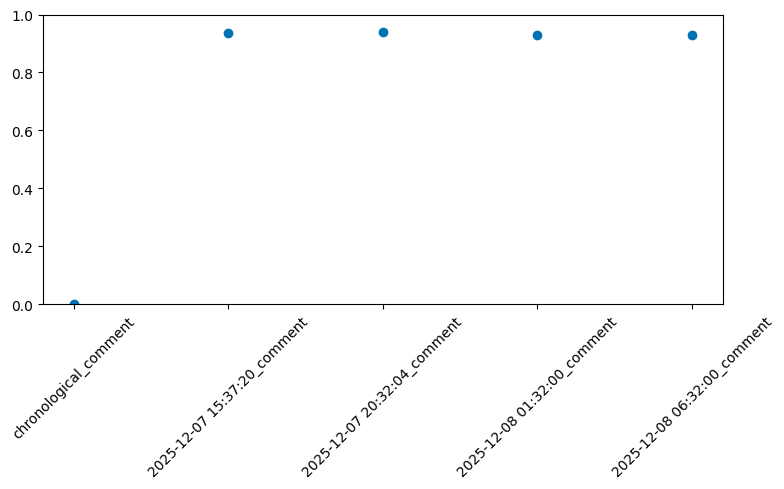

In [23]:
plt.figure(figsize=(8, 5))
plt.scatter(range(len(false_ratio)), false_ratio['chronological_comment'])
plt.ylim(0, 1)
plt.xticks(range(len(false_ratio)), false_ratio.index, rotation=45)
plt.tight_layout()
plt.show()


### Comments saturation

In [11]:
filepath = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/new/saturation'

In [37]:
comments = {}

for x in os.listdir(filepath):
    if 'control' in x and 'timestamps' not in x:
        print(x)
        with open(f'{filepath}/{x}', 'r') as fp:
            data = json.load(fp)

        timestamp = x.split('data_')[1]

        
        if data:
            for k, v in data.items():
                if k not in comments:
                    comments[k] = {}

                if len(v) == 2:
                    num = v[1].lower()
                    if 'k' in num:
                        num = num.replace('k', '')
                        num = float(num)*1000
                    else:
                        num = float(v[1])
                    comments[k][timestamp] = num
                elif len(v) == 1:
                    comments[k][timestamp] = 0
                else:
                    print(len(v), 'mismatch') 


control_metrics_data_2025-12-24 00:33:00
control_metrics_data_2025-12-24 04:33:00
control_metrics_data_2025-12-23 21:33:56
control_metrics_data_2025-12-24 08:33:00


In [38]:
comments_df = pd.DataFrame.from_dict(comments).T
comments_df = comments_df[['2025-12-23 21:33:56', '2025-12-24 00:33:00', '2025-12-24 04:33:00']]
comments_df

,2025-12-23 21:33:56,2025-12-24 00:33:00,2025-12-24 04:33:00
DSnZznKk6Ud,NaN,342.0,386.0
DSnFCE4iUdA,0.0,0.0,0.0
DSlQHB9kcRS,5.0,5.0,5.0
DSk4bzkklJh,5.0,5.0,5.0
DSi4YrUjaH6,6700.0,6800.0,6800.0
...,...,...,...
DSnbubakntG,2600.0,NaN,NaN
DSnUntGFGBE,432.0,NaN,NaN
DSnTt82kvnQ,423.0,NaN,NaN
DSnSXZ4EuEx,759.0,NaN,NaN


In [39]:
comments_df.dropna()

,2025-12-23 21:33:56,2025-12-24 00:33:00,2025-12-24 04:33:00
DSnFCE4iUdA,0.0,0.0,0.0
DSlQHB9kcRS,5.0,5.0,5.0
DSk4bzkklJh,5.0,5.0,5.0
DSi4YrUjaH6,6700.0,6800.0,6800.0
DSdob6dll7X,47.0,47.0,47.0
DSdh6ZVE5NV,60.0,60.0,60.0
DSdXRN5EghC,227.0,227.0,227.0
DSdNuHWE2wm,126.0,126.0,126.0
DScyv4ODNA-,1200.0,1200.0,1200.0
DSa2wMEjyNw,66.0,66.0,66.0


In [40]:
with open('/Users/brahmaninutakki/saarland/insta-comments/saved_data/new/saturation/control_timestamps_data_2025-12-23 21:33:56', 'r') as fp:
    timestamp_data = json.load(fp)

In [47]:
timestamp_df = pd.DataFrame.from_dict(timestamp_data).T
timestamp_df.rename(columns={'0': 'timestamp'}, inplace=True)

In [51]:
pd.merge(comments_df, timestamp_df, left_index=True, right_index=True).dropna()

,2025-12-23 21:33:56,2025-12-24 00:33:00,2025-12-24 04:33:00,0
DSnFCE4iUdA,0.0,0.0,0.0,2025-12-23T15:30:22.000Z
DSlQHB9kcRS,5.0,5.0,5.0,2025-12-22T22:12:28.000Z
DSk4bzkklJh,5.0,5.0,5.0,2025-12-22T18:46:18.000Z
DSi4YrUjaH6,6700.0,6800.0,6800.0,2025-12-22T00:07:12.000Z
DSdob6dll7X,47.0,47.0,47.0,2025-12-20T00:00:29.000Z
DSdh6ZVE5NV,60.0,60.0,60.0,2025-12-19T22:15:24.000Z
DSdXRN5EghC,227.0,227.0,227.0,2025-12-19T21:00:08.000Z
DSdNuHWE2wm,126.0,126.0,126.0,2025-12-19T19:20:43.000Z
DScyv4ODNA-,1200.0,1200.0,1200.0,2025-12-19T15:22:01.000Z
DSa2wMEjyNw,66.0,66.0,66.0,2025-12-18T23:00:30.000Z
